# IWSLT14 German → English Transformer (Phase 2)

Phase 2: rebuilding the phase 1 (IWSLT17) pipeline for the canonical IWSLT14 de-en benchmark, so results are directly comparable to published work. Planned additions on top of the phase 1 base: relative positional encoding, a short-to-long sequence-length training curriculum, and AdamW from the start. Phase 1's finished result is preserved at git tag `v1-iwslt17` and in `phase1_iwslt17.ipynb`.

In [1]:
import yaml
import torch

In [2]:
with open("config_iwslt14.yaml", "r") as f:
    config = yaml.safe_load(f)

device = torch.device(config['experiment']['device'] if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
if torch.cuda.is_available():
    # Disable Flash Attention lookup (suppresses Windows build warning)
    torch.backends.cuda.enable_flash_sdp(False)
    
    # Enable Memory-Efficient Attention & cuDNN Attention
    torch.backends.cuda.enable_mem_efficient_sdp(True)
    torch.backends.cuda.enable_math_sdp(True)

## Data Preparation

In [4]:
RESET_DATASET = False  # set True to wipe cached data/tokenizers and force a rebuild

if RESET_DATASET:
    from data_management import reset_dataset_cache
    reset_dataset_cache(folders=('./data_iwslt14', './cache_iwslt14', './models_iwslt14'))

In [5]:
from data_preparation import prepare_data_iwslt14
from dataset import get_dataloaders, create_single_dataloader, create_bpe_dropout_dataloader

USE_BPE_DROPOUT = True  # set False to train on fixed pre-tokenized ids like before

# 1. Download (canonical IWSLT14 de-en split, see data_preparation.py), tokenize,
# and load splits from cache
train_de, train_en, val_de, val_en, test_de, test_en, de_tok, en_tok, train_src_raw, train_tgt_raw = prepare_data_iwslt14(
    config=config,
    force_rebuild=False
)

# 2. Build Train and Val loaders
if USE_BPE_DROPOUT:
    # On-the-fly sampled tokenization — same sentence segments differently each
    # epoch, unlike the fixed pre-tokenized ids used everywhere else.
    train_loader = create_bpe_dropout_dataloader(
        src_texts=train_src_raw, tgt_texts=train_tgt_raw,
        src_tokenizer=de_tok, tgt_tokenizer=en_tok,
        alpha=config['training'].get('bpe_dropout_alpha', 0.1),
        batch_size=config['training']['batch_size'],
        shuffle=True
    )
else:
    train_loader, _ = get_dataloaders(
        train_src=train_de, train_tgt=train_en,
        val_src=val_de, val_tgt=val_en,
        batch_size=config['training']['batch_size'],
        num_workers=config['training'].get('num_workers', 0)
    )

val_loader = create_single_dataloader(
    src_encoded=val_de,
    tgt_encoded=val_en,
    batch_size=config['training']['batch_size'],
    shuffle=False,
    num_workers=config['training'].get('num_workers', 0)
)

# 3. Build Test loader independently
test_loader = create_single_dataloader(
    src_encoded=test_de,
    tgt_encoded=test_en,
    batch_size=config['training']['batch_size'],
    shuffle=False,
    num_workers=config['training'].get('num_workers', 0)
)

print(f"DataLoaders ready! Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

C:\Users\Tommi\Desktop\Transformer\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[data_prep] Loading pre-tokenized IWSLT14 dataset from cache './cache_iwslt14\processed_token_data.pkl'...
DataLoaders ready! Train: 2488 | Val: 114 | Test: 106


In [6]:
RUN_BENCHMARKS = True  # set True to time the dataloader in isolation from GPU compute

if RUN_BENCHMARKS:
    from benchmarking import benchmark_dataloader
    benchmark_dataloader(train_loader, num_batches=100)
else:
    print("RUN_BENCHMARKS is False — skipping dataloader speed test.")

Time taken for 100 DataLoader batches: 0.78 seconds


In [7]:
from inspection import inspect_dataset_samples
# Inspect 3 samples from the training set
inspect_dataset_samples(
    src_encoded=train_de,
    tgt_encoded=train_en,
    src_tokenizer=de_tok,
    tgt_tokenizer=en_tok,
    num_samples=3,
    start_idx=0
)

 DATASET INSPECTION (3 samples starting from index 0)

--- [ Sample #1 ] ---

🇩🇪 SOURCE (German):
  • Plain Text: Das Meer kann ziemlich kompliziert sein.
  • Token IDs (9): [1, 182, 1898, 247, 976, 6062, 232, 9944, 2]
  • Subword Pieces: ['<s>', '▁Das', '▁Meer', '▁kann', '▁ziemlich', '▁kompliziert', '▁sein', '.', '</s>']

🇬🇧 TARGET (English):
  • Plain Text: It can be a very complicated thing, the ocean.
  • Token IDs (13): [1, 177, 116, 61, 6, 228, 2724, 212, 9953, 8, 1687, 9955, 2]
  • Subword Pieces: ['<s>', '▁It', '▁can', '▁be', '▁a', '▁very', '▁complicated', '▁thing', ',', '▁the', '▁ocean', '.', '</s>']

--- [ Sample #2 ] ---

🇩🇪 SOURCE (German):
  • Plain Text: Und was menschliche Gesundheit ist, kann auch ziemlich kompliziert sein.
  • Token IDs (14): [1, 111, 192, 2034, 1370, 58, 9941, 247, 258, 976, 6062, 232, 9944, 2]
  • Subword Pieces: ['<s>', '▁Und', '▁was', '▁menschliche', '▁Gesundheit', '▁ist', ',', '▁kann', '▁auch', '▁ziemlich', '▁kompliziert', '▁sein', '.', '</s>']

🇬

## Hyperparameter Tuning (Optuna)

In [8]:
RUN_TUNING = False  # set True to run the Optuna hyperparameter search (slow)

if RUN_TUNING:
    from tuning import run_hyperparameter_search
    study = run_hyperparameter_search(
        train_loader, val_loader, config, device,
        n_trials=8,
        study_name="transformer_tuning_10",
        best_params_path="best_params_10k_vocab.json",
    )
else:
    print("RUN_TUNING is False — skipping hyperparameter search.")

RUN_TUNING is False — skipping hyperparameter search.


In [9]:
# Manual recovery: use this if RUN_TUNING above got interrupted (kernel restart,
# stalled/swapped to RAM, KeyboardInterrupt, etc.) before it could save best_params.json
# automatically. Completed trials persist in the storage DB regardless of how the
# process ended, so this just reloads the study and saves the best result found so far.
import optuna
from tuning import save_best_params

RUN_MANUAL_RECOVERY = False  # set True to use this cell — already recovered, best_params_10k_vocab.json exists

if RUN_MANUAL_RECOVERY:
    study = optuna.load_study(study_name="transformer_tuning_10", storage="sqlite:///optuna_study.db")
    save_best_params(study, best_params_path="best_params_10k_vocab.json")

In [10]:
import json

APPLY_BEST_PARAMS = True  # set False to train with the base config.yaml architecture instead

if APPLY_BEST_PARAMS:
    with open("best_params_10k_vocab.json", "r") as f:
        best_params_record = json.load(f)

    best_params = best_params_record["best_params"]
    print(
        f"Applying best params from trial {best_params_record['best_trial_number']} "
        f"(val_loss={best_params_record['best_value']:.4f}):\n{json.dumps(best_params, indent=2)}"
    )

    config['model']['d_model'] = best_params['d_model']
    config['model']['num_heads'] = best_params['nhead']
    config['model']['num_enc_layers'] = best_params['num_encoder_layers']
    config['model']['num_dec_layers'] = best_params['num_decoder_layers']
    config['model']['dropout'] = best_params['dropout']

    # weight_decay wasn't tunable in older best_params.json files — fall back to the
    # existing config value if this one predates that change, rather than KeyError.
    config['training']['weight_decay'] = best_params.get(
        'weight_decay', config['training'].get('weight_decay', 0.01)
    )

    # NOTE: best_params['lr'] is intentionally NOT applied below. Tuning trials used a
    # flat Adam lr with no schedule (tuning.py), but the final run below uses
    # CustomWarmupSchedule (Noam-style), which computes its own peak LR from
    # d_model/warmup_steps and expects optimizer lr=1.0 as a multiplier. The tuned lr
    # value isn't directly comparable/transferable to that setup.
else:
    print("APPLY_BEST_PARAMS is False — training with the base config.yaml architecture.")

Applying best params from trial 47 (val_loss=3.7378):
{
  "d_model": 256,
  "nhead": 4,
  "num_encoder_layers": 3,
  "num_decoder_layers": 4,
  "dropout": 0.1013563838218435,
  "weight_decay": 0.00010174227319105348
}


## Model & Trainer Setup

In [11]:
from model import Transformer  # Ensure model.py defines your Transformer class


src_vocab_size = de_tok.vocab_size
tgt_vocab_size = en_tok.vocab_size


model = Transformer(
    num_enc_layers=config['model']['num_enc_layers'],
    num_dec_layers=config['model']['num_dec_layers'],
    d_model=config['model']['d_model'],
    num_heads=config['model']['num_heads'],
    dff=config['model']['dff'],
    src_vocab=src_vocab_size,
    tgt_vocab=tgt_vocab_size,
    max_pe_src=config['model']['max_pe_source'],
    max_pe_tgt=config['model']['max_pe_target'],
    rate=config['model']['dropout']
).to(device)

# 4. Count total trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Transformer instantiated successfully!")
print(f"  • Source Vocab Size: {src_vocab_size:,}")
print(f"  • Target Vocab Size: {tgt_vocab_size:,}")
print(f"  • Total Trainable Parameters: {trainable_params:,}")

Transformer instantiated successfully!
  • Source Vocab Size: 10,000
  • Target Vocab Size: 10,000
  • Total Trainable Parameters: 17,951,248


In [12]:
if RUN_BENCHMARKS:
    import copy
    import torch.nn as nn
    from benchmarking import benchmark_step_time

    # Benchmark a disposable copy — benchmark_step_time performs real
    # backward()/optimizer.step() calls, which would otherwise nudge the actual
    # weights away from their tuned initialization before real training starts.
    _bench_model = copy.deepcopy(model)
    _bench_optimizer = torch.optim.AdamW(_bench_model.parameters(), lr=1e-4)
    _bench_criterion = nn.CrossEntropyLoss(
        label_smoothing=config['training'].get('label_smoothing_eps', 0.1),
        ignore_index=config['data'].get('pad_id', 0)
    )
    benchmark_step_time(_bench_model, _bench_optimizer, _bench_criterion, train_loader, device)
    del _bench_model, _bench_optimizer, _bench_criterion
else:
    print("RUN_BENCHMARKS is False — skipping GPU step-time benchmark.")

Warming up GPU...


C:\Users\Tommi\Desktop\Transformer\model.py:53: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  out = F.scaled_dot_product_attention(


Benchmarking 20 steps...

Pure GPU compute time per batch step: 56.69 ms


In [13]:
from tracker import ExperimentLogger
from trainer import Trainer
from scheduling import CustomWarmupSchedule


# Load best config from Optuna search
logger = ExperimentLogger(
    config=config,
    group="final_model",
    run_name="transformer_best_run"
)

# 1. Optimizer (Set lr=1.0 because CustomWarmupSchedule scales base_lr directly)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1.0,
    betas=(0.9, 0.98),
    eps=1e-9,
    weight_decay=config['training'].get('weight_decay', 0.01)
)

# 2. Instantiate CustomWarmupSchedule with your class name
scheduler = CustomWarmupSchedule(
    optimizer=optimizer,
    d_model=config['model']['d_model'],
    warmup_steps=config['training'].get('warmup_steps', 4000)
)

# 3. Mixed Precision Scaler
scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))

# 4. Instantiate SingleGPUTrainer
trainer = Trainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    device=device,
    config=config,
    logger=logger
)

print("Optimizer, CustomWarmupSchedule, Scaler, and Trainer successfully initialized!")

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Tommi\.netrc.
wandb: Currently logged in as: purplewaterfall (rl_project1) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: Detected [huggingface_hub.inference] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


Optimizer, CustomWarmupSchedule, Scaler, and Trainer successfully initialized!


## Training

Initial 20-epoch run below, followed by several resumed sessions.

In [15]:
from evaluation import evaluate_translation_metrics

def translation_eval_fn():
    # Fast greedy decoding for per-epoch progress checks during training — beam
    # search is reserved for the final evaluation cell below, since it's much
    # slower per-sentence and would meaningfully slow down every training epoch.
    return evaluate_translation_metrics(
        model=model,
        dataloader=val_loader,
        src_tokenizer=de_tok,
        tgt_tokenizer=en_tok,
        device=device,
        max_len=50,
        use_beam_search=False
    )

trainer.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=config['training']['epochs'],
    translation_eval_fn=translation_eval_fn
)

Starting training on device 'cuda' for epochs 1-20...
Epoch [1/20] | Train Loss: 6.5374 (PPL: 690.52) | Val Loss: 5.9951 (PPL: 401.47) | Duration: 140.7s
  BLEU: 0.20 | chrF: 10.93 | TER: 104.10
  Saved new best checkpoint to './checkpoints/de_en\best_model.pth' (Val Loss: 5.9951)
Epoch [2/20] | Train Loss: 5.5295 (PPL: 252.02) | Val Loss: 5.6419 (PPL: 281.99) | Duration: 142.9s
  BLEU: 0.52 | chrF: 13.67 | TER: 103.07
  Saved new best checkpoint to './checkpoints/de_en\best_model.pth' (Val Loss: 5.6419)
Epoch [3/20] | Train Loss: 5.2108 (PPL: 183.24) | Val Loss: 5.1154 (PPL: 166.56) | Duration: 141.1s
  BLEU: 2.43 | chrF: 18.51 | TER: 98.16
  Saved new best checkpoint to './checkpoints/de_en\best_model.pth' (Val Loss: 5.1154)
Epoch [4/20] | Train Loss: 4.8175 (PPL: 123.66) | Val Loss: 4.6096 (PPL: 100.44) | Duration: 140.5s
  BLEU: 5.27 | chrF: 24.41 | TER: 88.81
  Saved new best checkpoint to './checkpoints/de_en\best_model.pth' (Val Loss: 4.6096)
Epoch [5/20] | Train Loss: 4.5582 (P

### Resuming Training Across Sessions

The run above stopped at epoch 20. Each cell below resumes from the best checkpoint saved so far and trains additional epochs — a real record of iterative training across several sessions (20→29, 29→39, 37→42, 39→44), not a single continuous run.

In [16]:
# Example: resuming training later (e.g. trained 20 epochs already, want 10 more).
# Run this in a FRESH kernel session — rebuild model/optimizer/scheduler/trainer
# with the exact same architecture as the run that produced the checkpoint
# (i.e. re-run the APPLY_BEST_PARAMS + model-build + trainer-setup cells above
# unchanged) before calling load_checkpoint, or load_state_dict will fail on a
# shape mismatch.





RESUME_FROM_CHECKPOINT = True  # set True to actually resume

if RESUME_FROM_CHECKPOINT:
    checkpoint_path = "./checkpoints/de_en/best_model.pth"
    trainer.load_checkpoint(checkpoint_path)  # restores model, optimizer, scheduler, global_step, best_val_loss

    # epochs here means "how many MORE epochs to run", not a new total —
    # this continues from wherever load_checkpoint left off (e.g. epoch 21-30)
    trainer.fit(
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=10,
        translation_eval_fn=translation_eval_fn
    )

Resumed from './checkpoints/de_en/best_model.pth': epoch 19, global_step 30609, best_val_loss 3.5526
Starting training on device 'cuda' for epochs 20-29...
Epoch [20/29] | Train Loss: 3.8383 (PPL: 46.45) | Val Loss: 3.5340 (PPL: 34.26) | Duration: 148.5s
  BLEU: 12.95 | chrF: 41.88 | TER: 68.62
  Saved new best checkpoint to './checkpoints/de_en\best_model.pth' (Val Loss: 3.5340)
Epoch [21/29] | Train Loss: 3.8280 (PPL: 45.97) | Val Loss: 3.5318 (PPL: 34.19) | Duration: 148.4s
  BLEU: 12.94 | chrF: 41.67 | TER: 69.28
  Saved new best checkpoint to './checkpoints/de_en\best_model.pth' (Val Loss: 3.5318)
Epoch [22/29] | Train Loss: 3.8193 (PPL: 45.57) | Val Loss: 3.5203 (PPL: 33.80) | Duration: 149.5s
  BLEU: 13.56 | chrF: 42.25 | TER: 68.15
  Saved new best checkpoint to './checkpoints/de_en\best_model.pth' (Val Loss: 3.5203)
Epoch [23/29] | Train Loss: 3.8114 (PPL: 45.21) | Val Loss: 3.5246 (PPL: 33.94) | Duration: 148.1s
  BLEU: 13.02 | chrF: 41.81 | TER: 72.60
Epoch [24/29] | Train L

In [17]:
RESUME_FROM_CHECKPOINT = True  # set True to actually resume

if RESUME_FROM_CHECKPOINT:
    checkpoint_path = "./checkpoints/de_en/best_model.pth"
    trainer.load_checkpoint(checkpoint_path)  # restores model, optimizer, scheduler, global_step, best_val_loss

    # epochs here means "how many MORE epochs to run", not a new total —
    # this continues from wherever load_checkpoint left off (e.g. epoch 21-30)
    trainer.fit(
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=10,
        translation_eval_fn=translation_eval_fn
    )

Resumed from './checkpoints/de_en/best_model.pth': epoch 29, global_step 46719, best_val_loss 3.4725
Starting training on device 'cuda' for epochs 30-39...
Epoch [30/39] | Train Loss: 3.7713 (PPL: 43.44) | Val Loss: 3.4738 (PPL: 32.26) | Duration: 146.0s
  BLEU: 13.95 | chrF: 42.90 | TER: 68.24
Epoch [31/39] | Train Loss: 3.7667 (PPL: 43.24) | Val Loss: 3.4645 (PPL: 31.96) | Duration: 162.1s
  BLEU: 13.52 | chrF: 43.26 | TER: 69.48
  Saved new best checkpoint to './checkpoints/de_en\best_model.pth' (Val Loss: 3.4645)
Epoch [32/39] | Train Loss: 3.7636 (PPL: 43.10) | Val Loss: 3.4726 (PPL: 32.22) | Duration: 172.2s
  BLEU: 13.76 | chrF: 43.15 | TER: 72.69
Epoch [33/39] | Train Loss: 3.7588 (PPL: 42.90) | Val Loss: 3.4445 (PPL: 31.33) | Duration: 172.8s
  BLEU: 13.92 | chrF: 43.46 | TER: 66.81
  Saved new best checkpoint to './checkpoints/de_en\best_model.pth' (Val Loss: 3.4445)
Epoch [34/39] | Train Loss: 3.7563 (PPL: 42.79) | Val Loss: 3.4586 (PPL: 31.77) | Duration: 176.4s
  BLEU: 13.

In [18]:
RESUME_FROM_CHECKPOINT = True  # set True to actually resume

if RESUME_FROM_CHECKPOINT:
    checkpoint_path = "./checkpoints/de_en/best_model.pth"
    trainer.load_checkpoint(checkpoint_path)  # restores model, optimizer, scheduler, global_step, best_val_loss

    # epochs here means "how many MORE epochs to run", not a new total —
    # this continues from wherever load_checkpoint left off (e.g. epoch 21-30)
    trainer.fit(
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=5,
        translation_eval_fn=translation_eval_fn
    )

Resumed from './checkpoints/de_en/best_model.pth': epoch 37, global_step 59607, best_val_loss 3.4258
Starting training on device 'cuda' for epochs 38-42...
Epoch [38/42] | Train Loss: 3.7437 (PPL: 42.25) | Val Loss: 3.4337 (PPL: 30.99) | Duration: 174.7s
  BLEU: 14.40 | chrF: 44.01 | TER: 65.78
Epoch [39/42] | Train Loss: 3.7427 (PPL: 42.21) | Val Loss: 3.4253 (PPL: 30.73) | Duration: 177.0s
  BLEU: 13.71 | chrF: 44.03 | TER: 67.64
  Saved new best checkpoint to './checkpoints/de_en\best_model.pth' (Val Loss: 3.4253)
Epoch [40/42] | Train Loss: 3.7398 (PPL: 42.09) | Val Loss: 3.4331 (PPL: 30.97) | Duration: 173.7s
  BLEU: 14.36 | chrF: 43.76 | TER: 65.81
Epoch [41/42] | Train Loss: 3.7379 (PPL: 42.01) | Val Loss: 3.4288 (PPL: 30.84) | Duration: 176.4s
  BLEU: 14.42 | chrF: 43.94 | TER: 66.49
Epoch [42/42] | Train Loss: 3.7361 (PPL: 41.93) | Val Loss: 3.4326 (PPL: 30.96) | Duration: 176.7s
  BLEU: 14.58 | chrF: 43.86 | TER: 65.40


In [16]:
RESUME_FROM_CHECKPOINT = True  # set True to actually resume

if RESUME_FROM_CHECKPOINT:
    checkpoint_path = "./checkpoints/de_en/best_model.pth"
    trainer.load_checkpoint(checkpoint_path)  # restores model, optimizer, scheduler, global_step, best_val_loss

    # epochs here means "how many MORE epochs to run", not a new total —
    # this continues from wherever load_checkpoint left off (e.g. epoch 21-30)
    trainer.fit(
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=5,
        translation_eval_fn=translation_eval_fn
    )

Resumed from './checkpoints/de_en/best_model.pth': epoch 39, global_step 62829, best_val_loss 3.4253
Starting training on device 'cuda' for epochs 40-44...
Epoch [40/44] | Train Loss: 3.7393 (PPL: 42.07) | Val Loss: 3.4240 (PPL: 30.69) | Duration: 146.8s
  BLEU: 14.28 | chrF: 44.11 | TER: 65.82 | NIST: 5.0209
  Saved new best checkpoint to './checkpoints/de_en\best_model.pth' (Val Loss: 3.4240)
Epoch [41/44] | Train Loss: 3.7376 (PPL: 42.00) | Val Loss: 3.4291 (PPL: 30.85) | Duration: 145.7s
  BLEU: 14.52 | chrF: 44.19 | TER: 67.33 | NIST: 5.0727
Epoch [42/44] | Train Loss: 3.7352 (PPL: 41.90) | Val Loss: 3.4264 (PPL: 30.77) | Duration: 148.6s
  BLEU: 14.37 | chrF: 43.51 | TER: 66.23 | NIST: 4.9863
Epoch [43/44] | Train Loss: 3.7335 (PPL: 41.83) | Val Loss: 3.4228 (PPL: 30.65) | Duration: 149.2s
  BLEU: 14.04 | chrF: 44.18 | TER: 74.65 | NIST: 4.9363
  Saved new best checkpoint to './checkpoints/de_en\best_model.pth' (Val Loss: 3.4228)
Epoch [44/44] | Train Loss: 3.7316 (PPL: 41.75) | 

## Evaluation

In [14]:
import os

# fit() leaves `model` holding the LAST epoch's weights, which may not be the best —
# reload the best checkpoint (lowest val_loss) before evaluating, since the cells
# below (translation demo, BLEU eval, attention plots) all operate on `model`.
trainer.load_checkpoint(os.path.join(trainer.save_dir, "best_model.pth"))

Resumed from './checkpoints/de_en\best_model.pth': epoch 43, global_step 69273, best_val_loss 3.4228


In [15]:
from generation import translate_sentence, translate_sentence_beam_search

sample = "Wir müssen diese Lösungen heute finden."
translation = "We have to find those solutions today."

# 1. Greedy Search (equivalent to beam_size=1)
greedy_res = translate_sentence(model, sample, de_tok, en_tok, device)

# 2. Beam Search k=4, default length penalty
beam_4_a06 = translate_sentence_beam_search(
    model, sample, de_tok, en_tok, device, beam_size=4, alpha=0.6
)

# 3. Beam Search k=4, stronger length penalty (encourages longer text)
beam_4_a12 = translate_sentence_beam_search(
    model, sample, de_tok, en_tok, device, beam_size=4, alpha=1.2
)

print(f"Source:      {sample}")
print(f"Source:      {translation}")
print(f"Greedy:      {greedy_res}")
print(f"Beam (k=4, α=0.6): {beam_4_a06}")
print(f"Beam (k=4, α=1.2): {beam_4_a12}")

Source:      Wir müssen diese Lösungen heute finden.
Source:      We have to find those solutions today.
Greedy:      We need to find these solutions today.
Beam (k=4, α=0.6): We need to find these solutions today.
Beam (k=4, α=1.2): We need to find these solutions today.


In [16]:
from evaluation import evaluate_translation_metrics

# Evaluated on test_loader (held out, never used for checkpoint selection or
# during-training progress checks), so this score is comparable to published
# benchmarks — val_loader was used for both model selection and reporting,
# which biases it slightly optimistic. Beam search decoding (default
# use_beam_search=True) — greedy decoding was producing degenerate repetition
# loops that understate real translation quality.
metrics = evaluate_translation_metrics(
    model=model,
    dataloader=test_loader,
    src_tokenizer=de_tok,
    tgt_tokenizer=en_tok,
    device=device,
    max_len=50
)

print(f"=== Translation Benchmark Results ===")
print(f"• SacreBLEU Score: {metrics['bleu']:.2f}")
print(f"• chrF Score:      {metrics['chrf']:.2f}")
print(f"• TER Score:       {metrics['ter']:.2f}")
print(f"• NIST Score:      {metrics['nist']:.4f}\n")

print("--- Generated Sample Comparison ---")
for idx, (hyp, ref) in enumerate(zip(metrics['sample_hyp'], metrics['sample_ref']), 1):
    print(f"[{idx}] Predicted: {hyp}")
    print(f"    Reference: {ref}\n")

=== Translation Benchmark Results ===
• SacreBLEU Score: 23.01
• chrF Score:      46.34
• TER Score:       61.65
• NIST Score:      6.2506

--- Generated Sample Comparison ---
[1] Predicted: Some years ago, at TED, Peter Skillman a design competition called "The Marsmallow House challenge."
    Reference: Several years ago here at TED, Peter Skillman introduced a design challenge called the marshmallow challenge.

[2] Predicted: The idea is pretty easy. Vermer's teams need to get the biggest possible free structure with 20 spagetti, about a black band, about 10 feet and a Marshallow.
    Reference: And the idea's pretty simple: Teams of four have to build the tallest free-standing structure out of 20 sticks of spaghetti, one yard of tape, one yard of string and a marshmallow.

[3] Predicted: Marshmallow needs to be up there.
    Reference: The marshmallow has to be on top.



## Attention Visualization

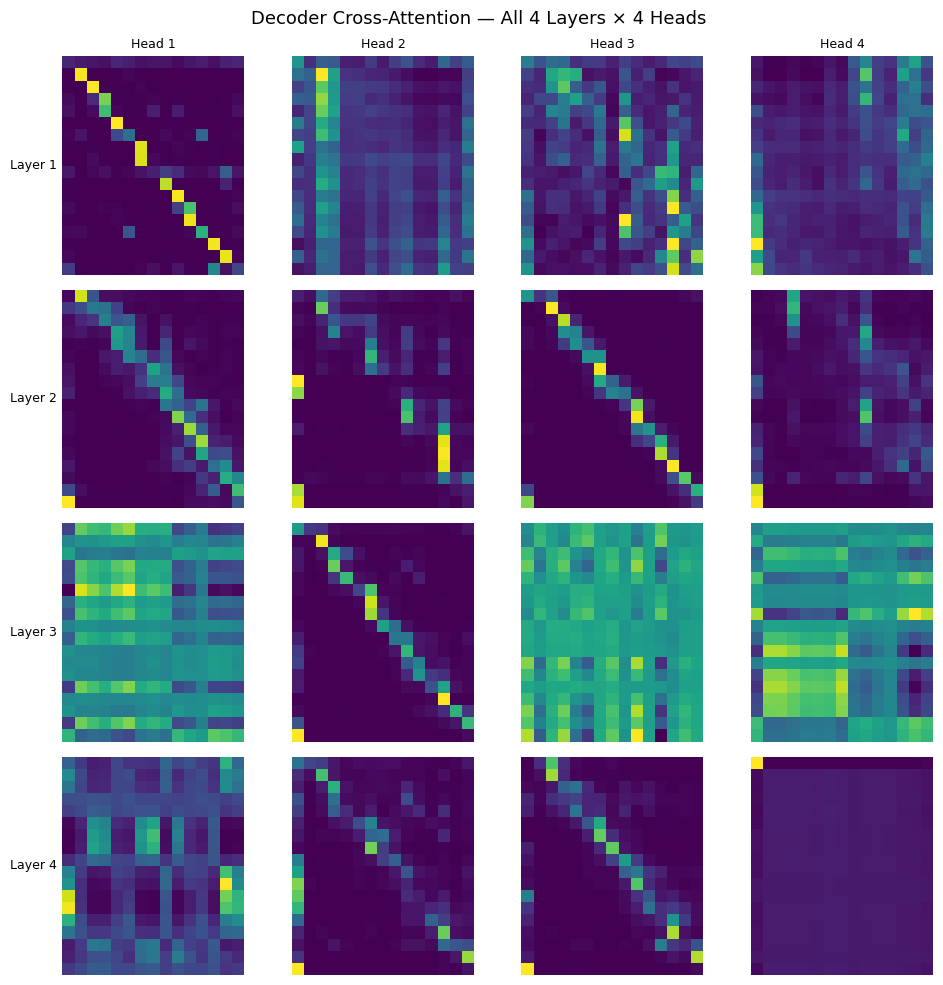

In [17]:
from visualization import plot_attention

# Grid of every decoder layer x every head at once, instead of one at a time.
# attn_type="cross" = decoder attending to source (same relation as the single
# heatmap above); "self" = decoder attending to its own previous tokens.
test_sentence = "Die Katze sitzt auf der Matte und schaut aus dem Fenster."

plot_attention(
    model=model,
    src_sentence=test_sentence,
    src_tokenizer=de_tok,
    tgt_tokenizer=en_tok,
    device=device,
    attn_type="cross",
    layer_idx=None,
    head_idx=None,
    save_path=None
)

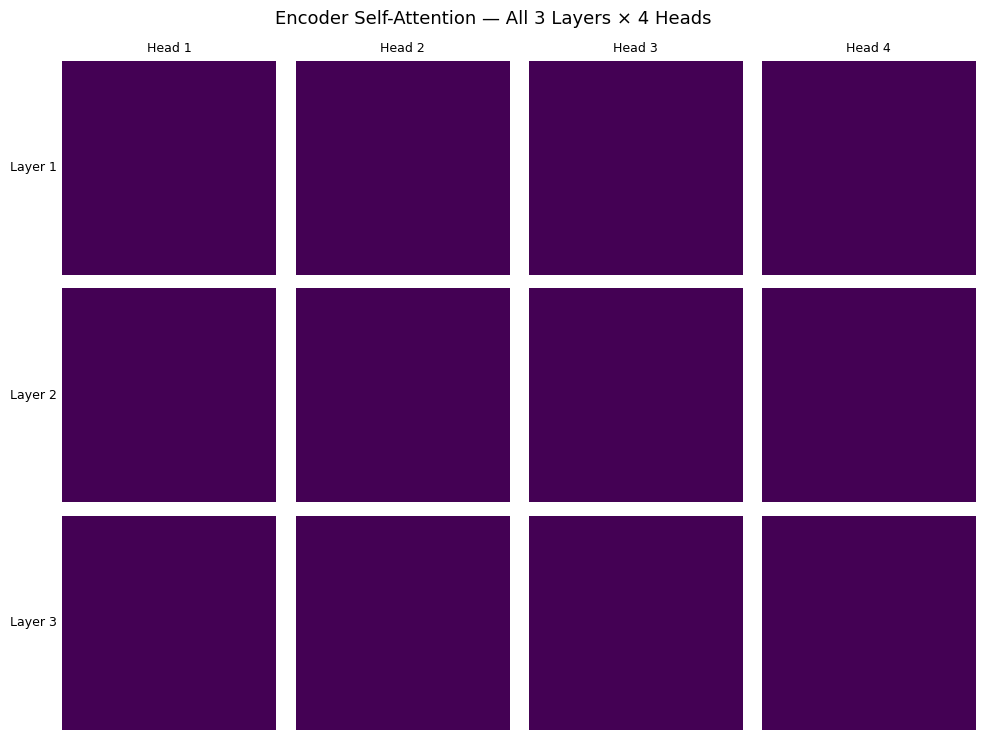

In [18]:
# Encoder self-attention — source tokens attending to each other. model.py's
# EncoderLayer.forward now captures and returns its attention weights too
# (enc_layer_{i}_self_attn), so this is plottable the same way as the decoder grids.
plot_attention(
    model=model,
    src_sentence=test_sentence,
    src_tokenizer=de_tok,
    tgt_tokenizer=en_tok,
    device=device,
    attn_type="encoder",
    layer_idx=None,
    head_idx=None,
    save_path=None
)

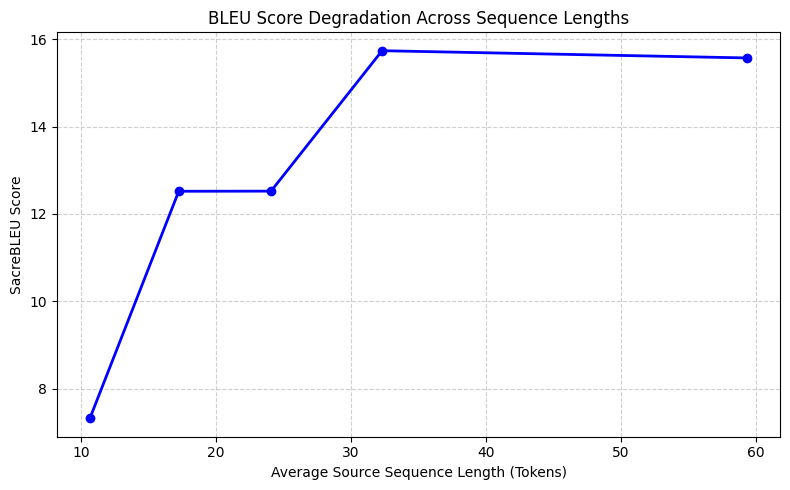

In [19]:
from evaluation import plot_bleu_vs_length

plot_bleu_vs_length(
    model=model,
    dataloader=val_loader,
    tgt_tokenizer=en_tok,
    device=device,
    max_len=50,
    num_bins=5
)

## Diagnosing and Fixing Collapsed Encoder Self-Attention

The encoder self-attention heatmaps above are perfectly uniform — every row is exactly `1/seq_len`, regardless of layer or head. Inspecting the checkpoint directly showed why: every encoder layer's query/key projection weights (`wq`, `wk` — weight *and* bias) had decayed to **exactly zero**, while the decoder's equivalent weights trained completely normally.

Two compounding causes:
1. **The encoder's gradient signal is inherently much weaker than the decoder's.** The loss is computed entirely from the decoder's output — the encoder only influences it indirectly, through the full decoder stack via cross-attention. Even at initialization, the encoder's `wq`/`wk` gradient was ~100x smaller than the decoder's.
2. **Weight decay was applied indiscriminately.** The optimizer was plain `Adam` (not `AdamW`), which mixes weight decay directly into the gradient rather than decoupling it, applied uniformly to *every* parameter including LayerNorm gains and biases — standard practice excludes those.

With a real gradient that weak, the decay term dominated every step and ground `wq`/`wk` down to zero over the ~141k steps of the full training run, leaving the encoder doing uniform averaging instead of learned attention. `wv` and the FFN kept training normally via the residual path, which is likely why the model still reached a reasonable ~14.5 BLEU despite this.

**Fix tested below:** fine-tune only the encoder (decoder frozen, for a clean before/after comparison) with `AdamW` and weight decay excluded from 1D parameters.

In [22]:
import copy
import math
import torch
import torch.nn as nn
from trainer import Trainer
from scheduling import CustomWarmupSchedule
from evaluation import evaluate_translation_metrics

def translation_eval_fn():
    # Fast greedy decoding for per-epoch progress checks during training — beam
    # search is reserved for the final evaluation cell below, since it's much
    # slower per-sentence and would meaningfully slow down every training epoch.
    return evaluate_translation_metrics(
        model=model,
        dataloader=val_loader,
        src_tokenizer=de_tok,
        tgt_tokenizer=en_tok,
        device=device,
        max_len=50,
        use_beam_search=False
    )

# Reload weights ONLY (not optimizer/scheduler state) from the checkpoint whose
# encoder self-attention collapsed under Adam's non-decoupled weight decay —
# switching to AdamW makes that checkpoint's optimizer state incompatible anyway.
ckpt = torch.load("./checkpoints/de_en/best_model.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])

# Re-initialize the collapsed enc wq/wk projections. They're exactly zero in the
# checkpoint, and q·k is bilinear in (wq, wk) — at q=k=0 the gradient w.r.t. wq is
# k=0 and w.r.t. wk is q=0, so it's a true fixed point of gradient descent. No
# optimizer can move them from here; they need their symmetry broken first.
# Matches nn.Linear's own default init (kaiming_uniform_ + fan-in bias bound).
for layer in model.enc_layers:
    for lin in (layer.mha.wq, layer.mha.wk):
        nn.init.kaiming_uniform_(lin.weight, a=math.sqrt(5))
        fan_in, _ = nn.init._calculate_fan_in_and_fan_out(lin.weight)
        bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
        nn.init.uniform_(lin.bias, -bound, bound)

# Freeze everything except the encoder, so this run isolates whether decoupled
# weight decay actually fixes the collapsed self-attention, without decoder
# drift muddying the before/after comparison.
ENCODER_MODULES = ("src_emb", "enc_layers", "encoder_norm")
for name, p in model.named_parameters():
    p.requires_grad = name.startswith(ENCODER_MODULES)

# AdamW with weight decay excluded from 1D params (LayerNorm gains, biases) —
# the original Adam run applied L2 decay to every parameter uniformly, which is
# what starved enc wq/wk of signal in the first place.
decay, no_decay = [], []
for p in model.parameters():
    if p.requires_grad:
        (no_decay if p.dim() == 1 else decay).append(p)

optimizer = torch.optim.AdamW(
    [
        {"params": decay, "weight_decay": config['training']['weight_decay']},
        {"params": no_decay, "weight_decay": 0.0},
    ],
    lr=1.0, betas=(0.9, 0.98), eps=1e-9
)

# Short warmup — fine-tuning from an already-converged checkpoint, not training
# from scratch, so a full 4000-step ramp would waste most of this run.
scheduler = CustomWarmupSchedule(optimizer, d_model=config['model']['d_model'], warmup_steps=400)
scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))

# Separate checkpoint dir — Trainer.fit() overwrites best_model.pth on every
# val_loss improvement, which would otherwise clobber the original checkpoint
# this run is meant to be compared against.
finetune_config = copy.deepcopy(config)
finetune_config['paths']['checkpoint_dir'] = './checkpoints/de_en_finetune'

finetune_trainer = Trainer(model, optimizer, scheduler, scaler, device, finetune_config, logger=None)
finetune_trainer.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=15,
    translation_eval_fn=translation_eval_fn
)

Starting training on device 'cuda' for epochs 1-15...
Epoch [1/15] | Train Loss: 3.7990 (PPL: 44.66) | Val Loss: 3.4817 (PPL: 32.51) | Duration: 115.2s
  BLEU: 13.68 | chrF: 42.22 | TER: 69.42 | NIST: 4.8589
  Saved new best checkpoint to './checkpoints/de_en_finetune\best_model.pth' (Val Loss: 3.4817)
Epoch [2/15] | Train Loss: 3.7290 (PPL: 41.64) | Val Loss: 3.4323 (PPL: 30.95) | Duration: 113.4s
  BLEU: 14.37 | chrF: 43.70 | TER: 68.17 | NIST: 5.0799
  Saved new best checkpoint to './checkpoints/de_en_finetune\best_model.pth' (Val Loss: 3.4323)
Epoch [3/15] | Train Loss: 3.7004 (PPL: 40.47) | Val Loss: 3.4095 (PPL: 30.25) | Duration: 113.6s
  BLEU: 14.70 | chrF: 44.32 | TER: 68.10 | NIST: 5.1446
  Saved new best checkpoint to './checkpoints/de_en_finetune\best_model.pth' (Val Loss: 3.4095)
Epoch [4/15] | Train Loss: 3.6869 (PPL: 39.92) | Val Loss: 3.3967 (PPL: 29.87) | Duration: 113.3s
  BLEU: 14.68 | chrF: 44.40 | TER: 68.00 | NIST: 5.1514
  Saved new best checkpoint to './checkpoi

In [23]:
FINETUNE_RESUME = False  # set True to continue the encoder-only fine-tune for 10 more epochs

if FINETUNE_RESUME:
    finetune_checkpoint_path = "./checkpoints/de_en_finetune/best_model.pth"
    finetune_trainer.load_checkpoint(finetune_checkpoint_path)

    finetune_trainer.fit(
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=1,
        translation_eval_fn=translation_eval_fn
    )

In [24]:
import os

# fit() leaves `model` holding the LAST epoch's weights — reload the best
# checkpoint from the fine-tune run (lowest val_loss) before evaluating below.
finetune_trainer.load_checkpoint(os.path.join(finetune_trainer.save_dir, "best_model.pth"))

Resumed from './checkpoints/de_en_finetune\best_model.pth': epoch 15, global_step 24165, best_val_loss 3.3606


### Results After the Fine-tune

Same test sentence and evaluation set as above, now on the encoder-fixed model, for a direct before/after comparison.

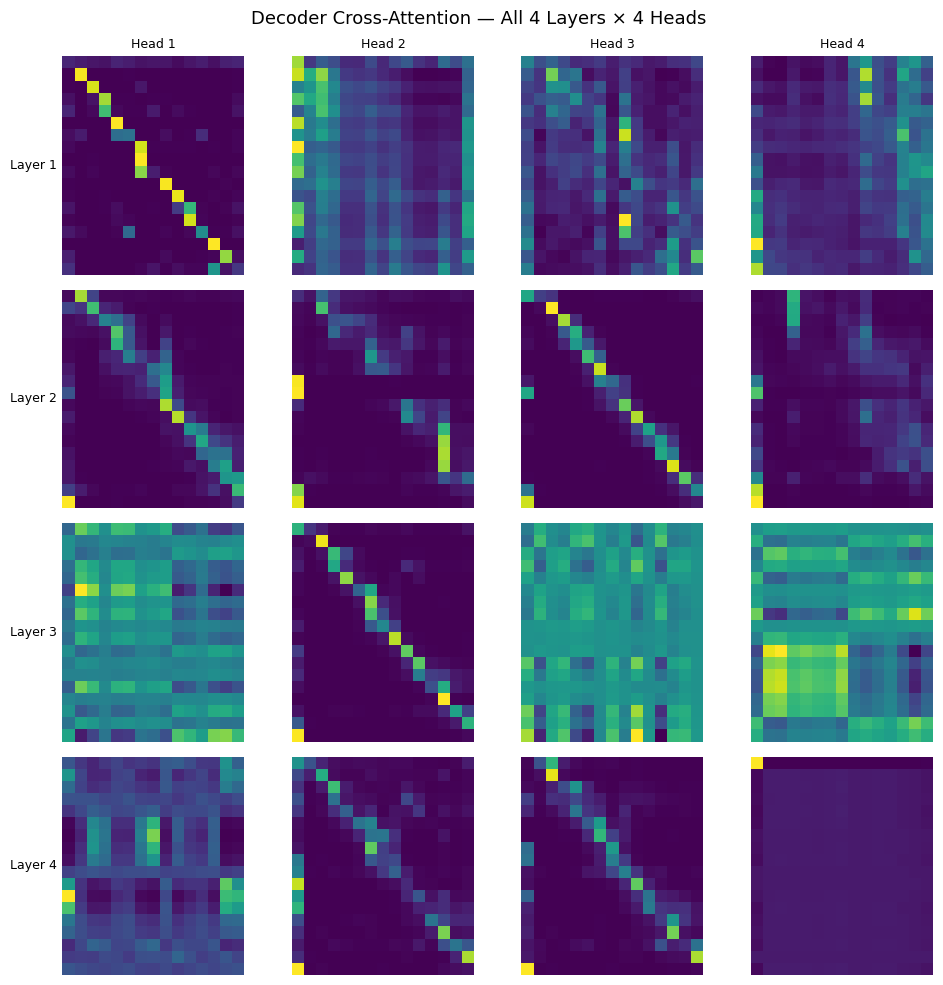

In [25]:
from visualization import plot_attention

# Cross-attention after the encoder-only AdamW fine-tune. Decoder weights are
# frozen, but the source representations it attends to changed since
# enc_layers/encoder_norm were retrained — worth comparing against the
# pre-fine-tune cross-attention grid above.
plot_attention(
    model=model,
    src_sentence=test_sentence,
    src_tokenizer=de_tok,
    tgt_tokenizer=en_tok,
    device=device,
    attn_type="cross",
    layer_idx=None,
    head_idx=None,
    save_path=None
)

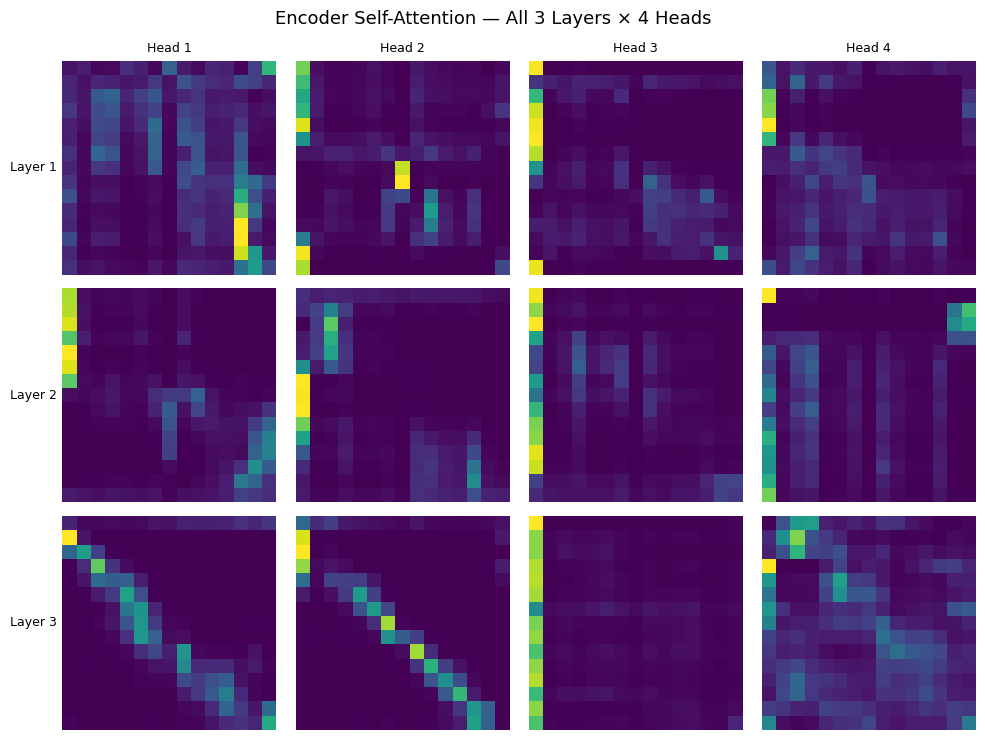

In [26]:
# Encoder self-attention after the fix — compare against the uniform 1/S grid
# from before the AdamW fine-tune (the "all purple" heatmaps).
plot_attention(
    model=model,
    src_sentence=test_sentence,
    src_tokenizer=de_tok,
    tgt_tokenizer=en_tok,
    device=device,
    attn_type="encoder",
    layer_idx=None,
    head_idx=None,
    save_path=None
)

In [27]:
from generation import translate_sentence, translate_sentence_beam_search

# Same sentence as the original model's translation demo, for a direct before/after read
greedy_res = translate_sentence(model, sample, de_tok, en_tok, device)
beam_4_a06 = translate_sentence_beam_search(model, sample, de_tok, en_tok, device, beam_size=4, alpha=0.6)
beam_4_a12 = translate_sentence_beam_search(model, sample, de_tok, en_tok, device, beam_size=4, alpha=1.2)

print(f"Source:      {sample}")
print(f"Reference:   {translation}")
print(f"Greedy:      {greedy_res}")
print(f"Beam (k=4, α=0.6): {beam_4_a06}")
print(f"Beam (k=4, α=1.2): {beam_4_a12}")

Source:      Wir müssen diese Lösungen heute finden.
Reference:   We have to find those solutions today.
Greedy:      We need to find these solutions today.
Beam (k=4, α=0.6): We need to find these solutions today.
Beam (k=4, α=1.2): We need to find these solutions today.


In [28]:
from evaluation import evaluate_translation_metrics

# Same held-out test set as the original model's benchmark. Named separately
# from `metrics` above so both results stay available to compare side by side.
# Beam search decoding — slow, this is the expensive one.
finetune_metrics = evaluate_translation_metrics(
    model=model,
    dataloader=test_loader,
    src_tokenizer=de_tok,
    tgt_tokenizer=en_tok,
    device=device,
    max_len=50
)

print(f"=== Fine-tuned Model — Translation Benchmark Results ===")
print(f"• SacreBLEU Score: {finetune_metrics['bleu']:.2f}")
print(f"• chrF Score:      {finetune_metrics['chrf']:.2f}")
print(f"• TER Score:       {finetune_metrics['ter']:.2f}")
print(f"• NIST Score:      {finetune_metrics['nist']:.4f}\n")

print("--- Generated Sample Comparison ---")
for idx, (hyp, ref) in enumerate(zip(finetune_metrics['sample_hyp'], finetune_metrics['sample_ref']), 1):
    print(f"[{idx}] Predicted: {hyp}")
    print(f"    Reference: {ref}\n")

=== Fine-tuned Model — Translation Benchmark Results ===
• SacreBLEU Score: 24.16
• chrF Score:      47.07
• TER Score:       60.08
• NIST Score:      6.4209

--- Generated Sample Comparison ---
[1] Predicted: A couple of years ago, at TED, Peter Skillman asked a design competition called "The Marshallow House challenge."
    Reference: Several years ago here at TED, Peter Skillman introduced a design challenge called the marshmallow challenge.

[2] Predicted: The idea is pretty simple. Verteams have to understand the biggest impossible structure with 20 spagetti, about a black band, building about a marsh
    Reference: And the idea's pretty simple: Teams of four have to build the tallest free-standing structure out of 20 sticks of spaghetti, one yard of tape, one yard of string and a marshmallow.

[3] Predicted: Marshallow has to be up there.
    Reference: The marshmallow has to be on top.



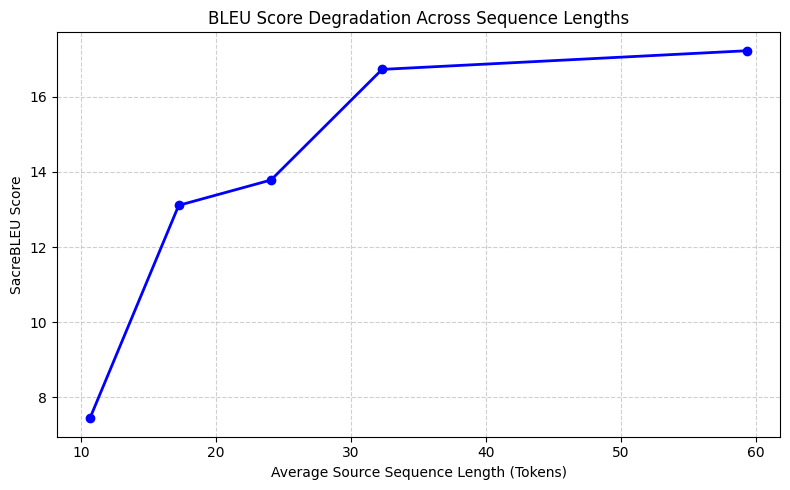

In [29]:
from evaluation import plot_bleu_vs_length

# Also decode-heavy (beam search across every length bin) — kept last with the
# other slow cell above rather than with the fast attention plots.
plot_bleu_vs_length(
    model=model,
    dataloader=val_loader,
    tgt_tokenizer=en_tok,
    device=device,
    max_len=50,
    num_bins=5
)

## Benchmarking Against the Official IWSLT17 Test Set

The evaluations above all use the HuggingFace `IWSLT/iwslt2017` loader's own `"test"` split — which, on inspection, turned out to actually be `tst2010`-`tst2015` concatenated (8,079 sentence pairs), not the official `tst2017` test set the dataset is named after. The cells below instead fetch the real `tst2017` de-en set (1,138 pairs) via `sacrebleu`'s built-in dataset registry, giving scores that are directly comparable to published IWSLT17 de-en benchmarks. First the fine-tuned model, then the original (pre-fine-tune) model for comparison.

In [31]:
import evaluation
import importlib
importlib.reload(evaluation)
from evaluation import evaluate_on_official_iwslt17

In [32]:
# `model` currently holds the fine-tuned (AdamW, re-initialized encoder) weights
# from the section above.
official_metrics_finetuned = evaluate_on_official_iwslt17(
    model=model,
    src_tokenizer=de_tok,
    tgt_tokenizer=en_tok,
    device=device
)

print("=== Fine-tuned Model — Official IWSLT17 (tst2017) Results ===")
print(f"• SacreBLEU Score: {official_metrics_finetuned['bleu']:.2f}")
print(f"• chrF Score:      {official_metrics_finetuned['chrf']:.2f}")
print(f"• TER Score:       {official_metrics_finetuned['ter']:.2f}")
print(f"• NIST Score:      {official_metrics_finetuned['nist']:.4f}")
print()

print("--- Generated Sample Comparison ---")
for idx, (hyp, ref) in enumerate(zip(official_metrics_finetuned['sample_hyp'], official_metrics_finetuned['sample_ref']), 1):
    print(f"[{idx}] Predicted: {hyp}")
    print(f"    Reference: {ref}")
    print()

=== Fine-tuned Model — Official IWSLT17 (tst2017) Results ===
• SacreBLEU Score: 18.30
• chrF Score:      41.69
• TER Score:       66.19
• NIST Score:      4.6501

--- Generated Sample Comparison ---
[1] Predicted: This is James Risse.
    Reference: So this is James Risen.

[2] Predicted: You may know him because he won the New York Times Reporters the Pulzer Price.
    Reference: You may know him as the Pulitzer Prize-winning reporter for The New York Times.

[3] Predicted: Long before someone who had heard of Edward Snowden, Risseen a book that he published in the spectacular, that the NSA is illegal telephone from Americans.
    Reference: Long before anybody knew Edward Snowden's name, Risen wrote a book in which he famously exposed that the NSA was illegally wiretapping the phone calls of Americans.



In [33]:
from evaluation import evaluate_on_official_iwslt17

# Reload the ORIGINAL (pre-fine-tune, collapsed-encoder) checkpoint into `model`
# for a direct before/after comparison on the official test set.
trainer.load_checkpoint("./checkpoints/de_en/best_model.pth")

official_metrics_original = evaluate_on_official_iwslt17(
    model=model,
    src_tokenizer=de_tok,
    tgt_tokenizer=en_tok,
    device=device
)

print("=== Original Model — Official IWSLT17 (tst2017) Results ===")
print(f"• SacreBLEU Score: {official_metrics_original['bleu']:.2f}")
print(f"• chrF Score:      {official_metrics_original['chrf']:.2f}")
print(f"• TER Score:       {official_metrics_original['ter']:.2f}")
print(f"• NIST Score:      {official_metrics_original['nist']:.4f}")
print()

print("--- Generated Sample Comparison ---")
for idx, (hyp, ref) in enumerate(zip(official_metrics_original['sample_hyp'], official_metrics_original['sample_ref']), 1):
    print(f"[{idx}] Predicted: {hyp}")
    print(f"    Reference: {ref}")
    print()

Resumed from './checkpoints/de_en/best_model.pth': epoch 43, global_step 69273, best_val_loss 3.4228
=== Original Model — Official IWSLT17 (tst2017) Results ===
• SacreBLEU Score: 17.19
• chrF Score:      41.04
• TER Score:       67.50
• NIST Score:      4.5699

--- Generated Sample Comparison ---
[1] Predicted: This is James Risen.
    Reference: So this is James Risen.

[2] Predicted: You may know him because he won the New York Times Reperter the Pulzer Pircle.
    Reference: You may know him as the Pulitzer Prize-winning reporter for The New York Times.

[3] Predicted: Long before someone had heard of Edward Snowden, wrote a book, in which he specularly published that the NSA illegal telephone from American.
    Reference: Long before anybody knew Edward Snowden's name, Risen wrote a book in which he famously exposed that the NSA was illegally wiretapping the phone calls of Americans.

